In [1]:
import os
print(os.getcwd())

C:\Users\varun


In [2]:
import sys
import numpy as np

print("Python version:")
print(sys.version)

print("\nPython location:")
print(sys.executable)

print("\nNumPy version:")
print(np.__version__)

Python version:
3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]

Python location:
D:\JUPYTER\python.exe

NumPy version:
2.4.6


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import MiniBatchKMeans

from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.inspection import permutation_importance

import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
!pip install -q ucimlrepo

print("UCI dataset package installed.")

UCI dataset package installed.


In [5]:
from ucimlrepo import fetch_ucirepo

# UCI Dataset ID 891
diabetes = fetch_ucirepo(id=891)

print("UCI CDC Diabetes Health Indicators dataset downloaded.")

UCI CDC Diabetes Health Indicators dataset downloaded.


In [6]:
X = diabetes.data.features.copy()

y = diabetes.data.targets.copy()

print("Feature shape:", X.shape)

print("Target shape:", y.shape)

Feature shape: (253680, 21)
Target shape: (253680, 1)


In [7]:
df = X.copy()

df["Diabetes_binary"] = y.iloc[:, 0].values

print("Complete dataset shape:", df.shape)

display(df.head())

Complete dataset shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [8]:
print("Number of observations:", df.shape[0])

print("Number of columns:", df.shape[1])

print("Number of predictor variables:", X.shape[1])

Number of observations: 253680
Number of columns: 22
Number of predictor variables: 21


In [9]:
print("Dataset Columns")
print("=" * 60)

for i, column in enumerate(df.columns, 1):

    print(f"{i:02d}. {column}")

Dataset Columns
01. HighBP
02. HighChol
03. CholCheck
04. BMI
05. Smoker
06. Stroke
07. HeartDiseaseorAttack
08. PhysActivity
09. Fruits
10. Veggies
11. HvyAlcoholConsump
12. AnyHealthcare
13. NoDocbcCost
14. GenHlth
15. MentHlth
16. PhysHlth
17. DiffWalk
18. Sex
19. Age
20. Education
21. Income
22. Diabetes_binary


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-null  int64


In [11]:
display(
    df.describe().T
)

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


In [12]:
missing_values = df.isnull().sum()

total_missing = missing_values.sum()

print("Total missing values:", total_missing)

if total_missing == 0:

    print("No missing values detected.")

else:

    display(
        missing_values[
            missing_values > 0
        ]
    )

Total missing values: 0
No missing values detected.


In [13]:
target_counts = df[
    "Diabetes_binary"
].value_counts().sort_index()

print(target_counts)

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64


In [14]:
target_percentage = (
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

target_percentage = target_percentage.round(2)

display(target_percentage)

Diabetes_binary
0    86.07
1    13.93
Name: proportion, dtype: float64

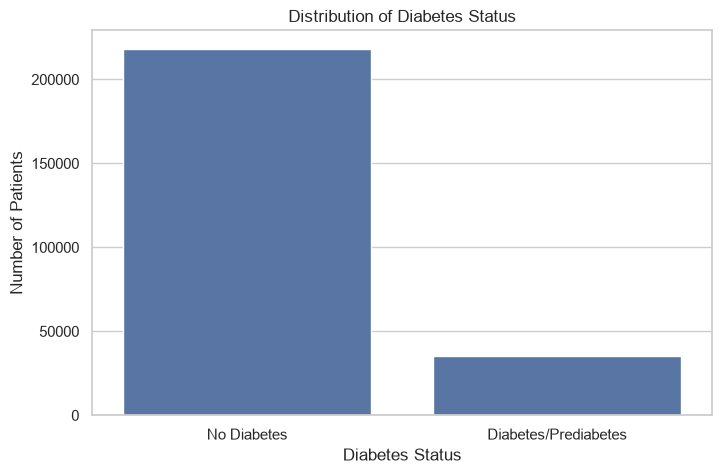

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Diabetes_binary"
)

plt.title(
    "Distribution of Diabetes Status"
)

plt.xlabel(
    "Diabetes Status"
)

plt.ylabel(
    "Number of Patients"
)

plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes/Prediabetes"]
)

plt.show()

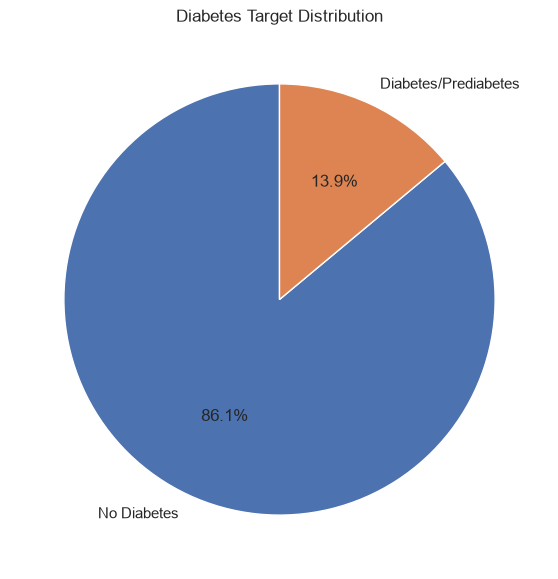

In [16]:
labels = [
    "No Diabetes",
    "Diabetes/Prediabetes"
]

values = df[
    "Diabetes_binary"
].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Diabetes Target Distribution"
)

plt.show()

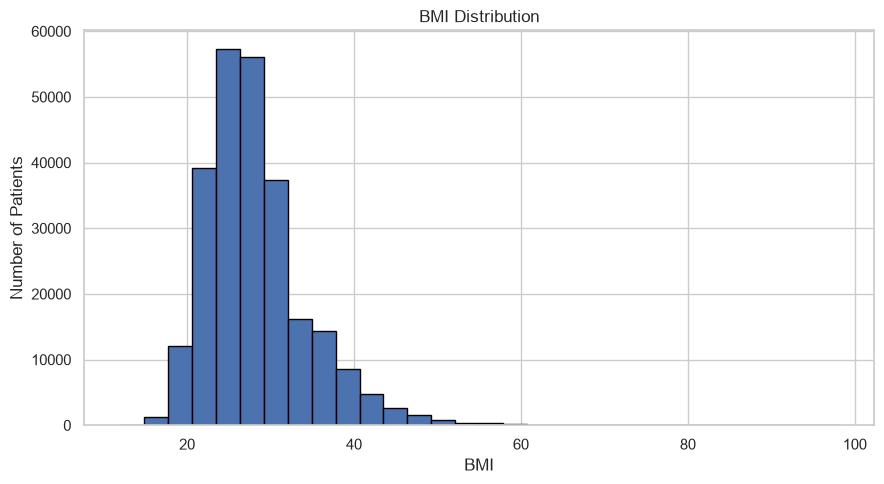

In [17]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["BMI"],
    bins=30,
    edgecolor="black"
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

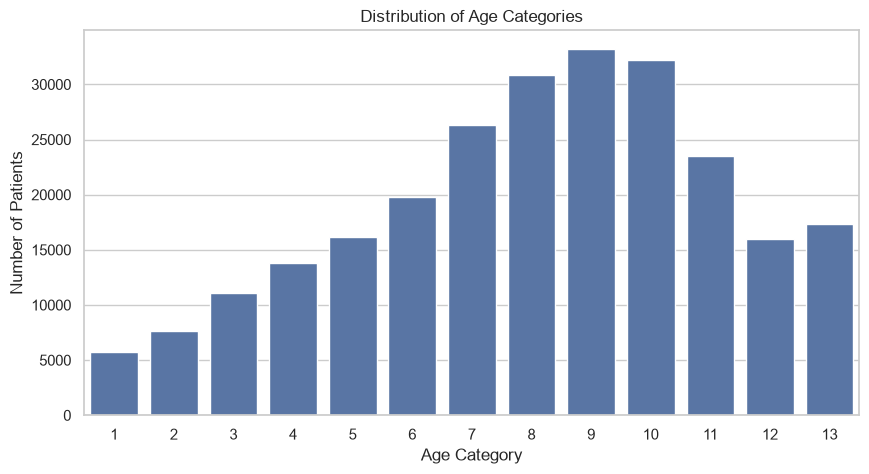

In [18]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Age"
)

plt.title(
    "Distribution of Age Categories"
)

plt.xlabel(
    "Age Category"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()

Diabetes percentage according to HighBP:


Diabetes_binary,0,1
HighBP,,
0,93.96,6.04
1,75.55,24.45


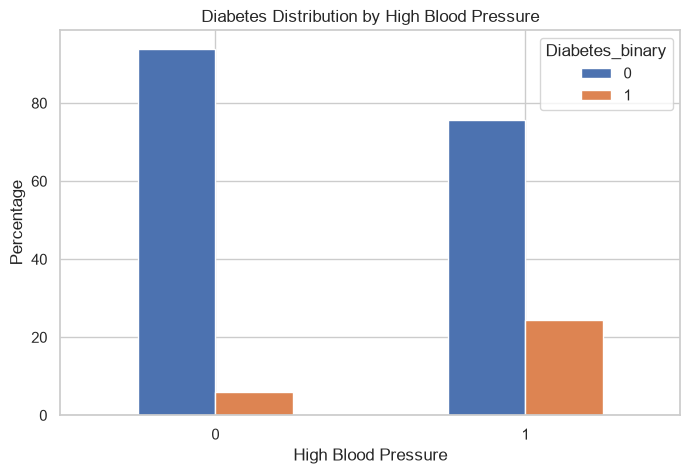

In [19]:
bp_table = pd.crosstab(
    df["HighBP"],
    df["Diabetes_binary"],
    normalize="index"
) * 100

print(
    "Diabetes percentage according to HighBP:"
)

display(
    bp_table.round(2)
)

bp_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Diabetes Distribution by High Blood Pressure"
)

plt.xlabel(
    "High Blood Pressure"
)

plt.ylabel(
    "Percentage"
)

plt.xticks(
    rotation=0
)
plt.savefig("High bloodpressure.png", dpi=600, bbox_inches="tight")

plt.show()

Diabetes_binary,0,1
HighChol,,
0,92.02,7.98
1,77.99,22.01


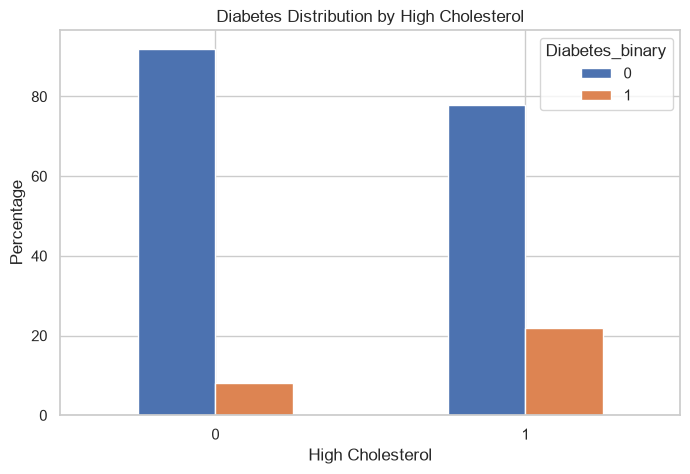

In [20]:
chol_table = pd.crosstab(
    df["HighChol"],
    df["Diabetes_binary"],
    normalize="index"
) * 100

display(
    chol_table.round(2)
)

chol_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Diabetes Distribution by High Cholesterol"
)

plt.xlabel(
    "High Cholesterol"
)

plt.ylabel(
    "Percentage"
)

plt.xticks(
    rotation=0
)
plt.savefig("high cholesterol.; c.png", dpi=600, bbox_inches="tight")

plt.show()

Diabetes_binary,0,1
HighChol,,
0,92.02,7.98
1,77.99,22.01


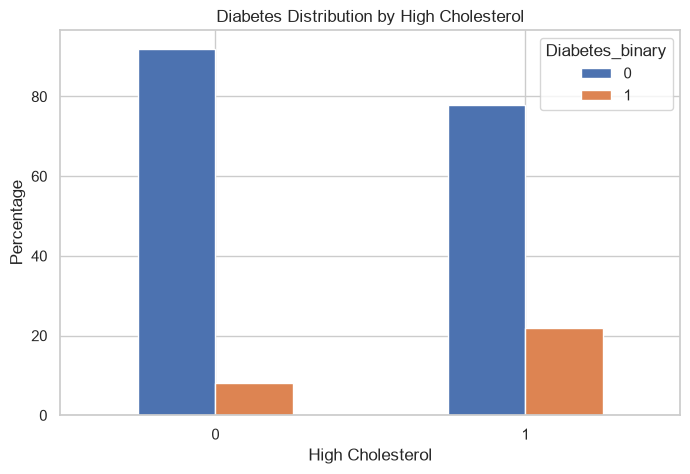

In [21]:
chol_table = pd.crosstab(
    df["HighChol"],
    df["Diabetes_binary"],
    normalize="index"
) * 100

display(
    chol_table.round(2)
)

chol_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Diabetes Distribution by High Cholesterol"
)

plt.xlabel(
    "High Cholesterol"
)

plt.ylabel(
    "Percentage"
)

plt.xticks(
    rotation=0
)
plt.savefig("high cholesterol.; c.png", dpi=600, bbox_inches="tight")
plt.show()

Diabetes_binary,0,1
Smoker,,
0,87.94,12.06
1,83.71,16.29


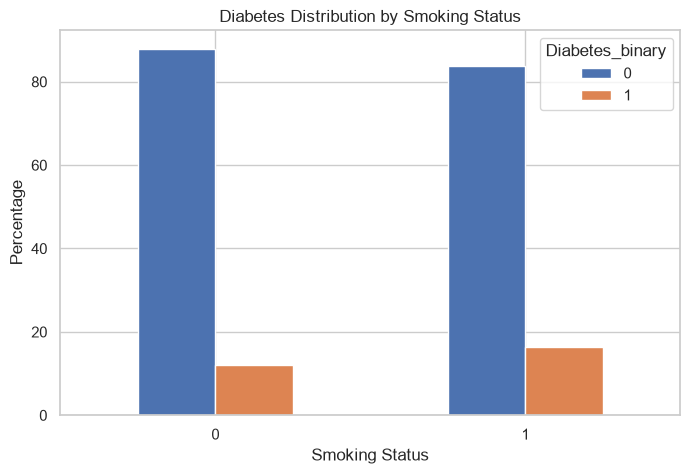

In [22]:
smoking_table = pd.crosstab(
    df["Smoker"],
    df["Diabetes_binary"],
    normalize="index"
) * 100

display(
    smoking_table.round(2)
)

smoking_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Diabetes Distribution by Smoking Status"
)

plt.xlabel(
    "Smoking Status"
)

plt.ylabel(
    "Percentage"
)

plt.xticks(
    rotation=0
)
plt.savefig("smoking.; c.png", dpi=600, bbox_inches="tight")
plt.show()

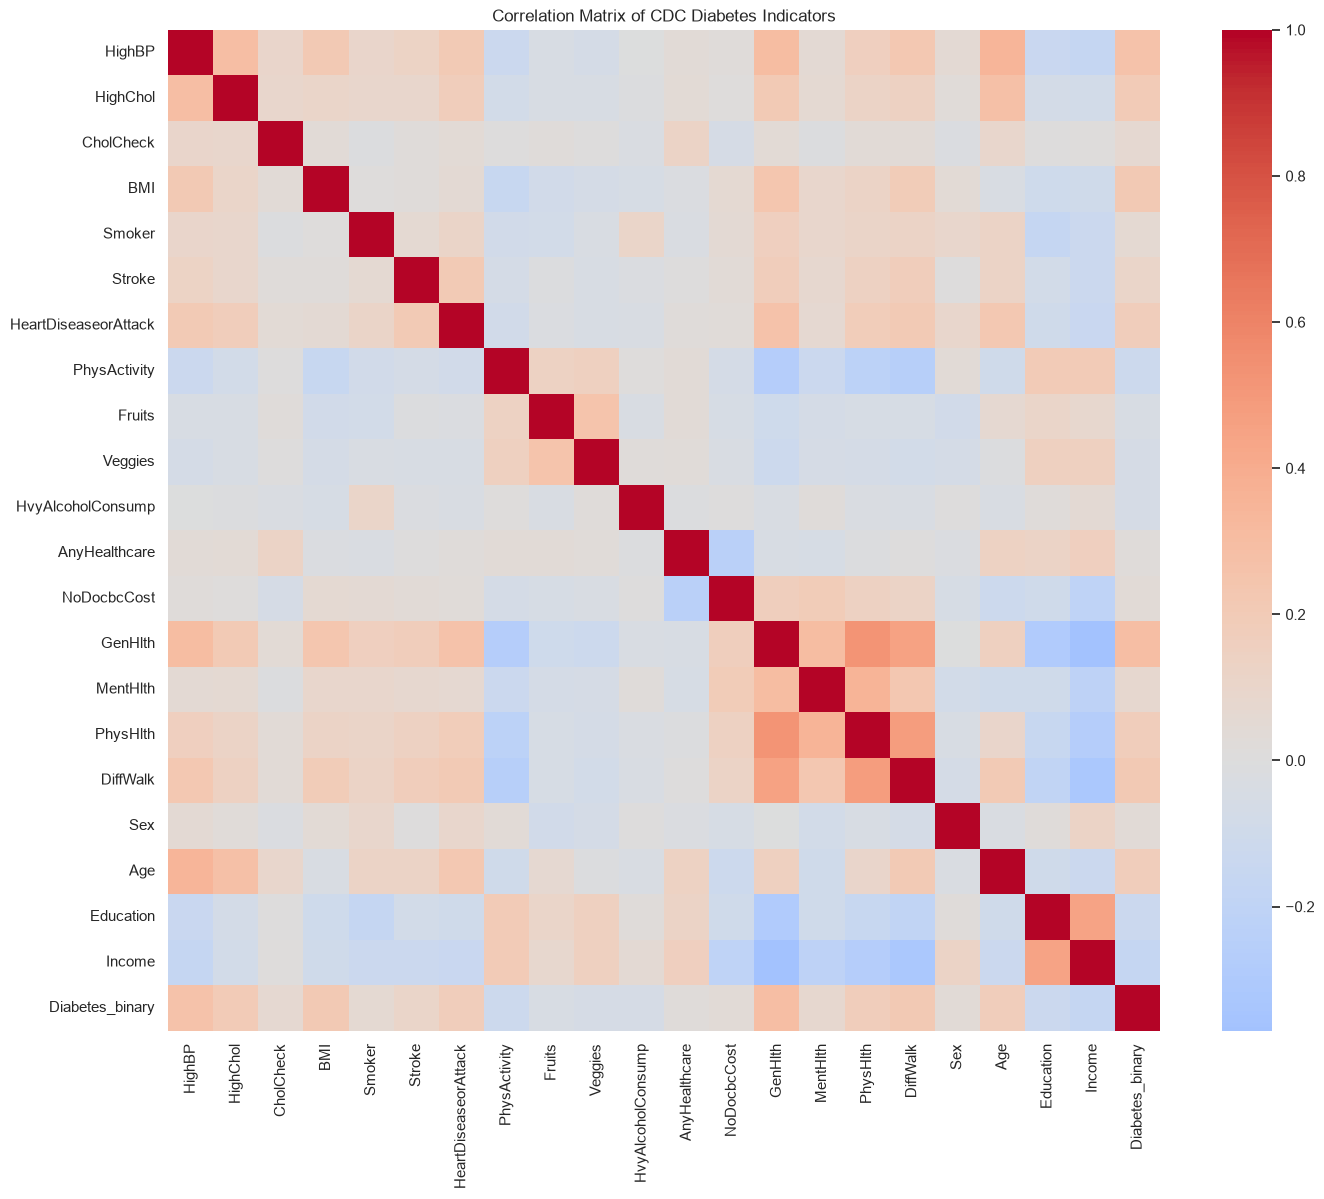

In [23]:
correlation_matrix = df.corr()

plt.figure(
    figsize=(16, 13)
)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix of CDC Diabetes Indicators"
)
plt.savefig("correlation matrix.; c.png", dpi=600, bbox_inches="tight")
plt.show()

## Data Preparation

The target variable is separated from the predictor variables.

The dataset is divided into three independent subsets:

- 70% Training
- 15% Validation
- 15% Testing

The validation data is used for determining profile-specific model
performance and adaptive ensemble weights.

The test set is kept independent for final evaluation.

In [24]:
X = df.drop(
    columns=["Diabetes_binary"]
)
a
y = df["Diabetes_binary"]

print(
    "Features:",
    X.shape
)

print(
    "Target:",
    y.shape
)

Features: (253680, 21)
Target: (253680,)


In [25]:
X = df.drop(
    columns=["Diabetes_binary"]
)

y = df["Diabetes_binary"]

print(
    "Features:",
    X.shape
)

print(
    "Target:",
    y.shape
)

Features: (253680, 21)
Target: (253680,)


In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(
    "Training set:",
    X_train.shape
)

print(
    "Validation set:",
    X_val.shape
)

print(
    "Testing set:",
    X_test.shape
)

Training set: (177576, 21)
Validation set: (38052, 21)
Testing set: (38052, 21)


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

print(
    "Feature scaling completed."
)

Feature scaling completed.


In [28]:
import threadpoolctl
print(threadpoolctl.__version__)

3.6.0


In [29]:
!pip install --upgrade threadpoolctl

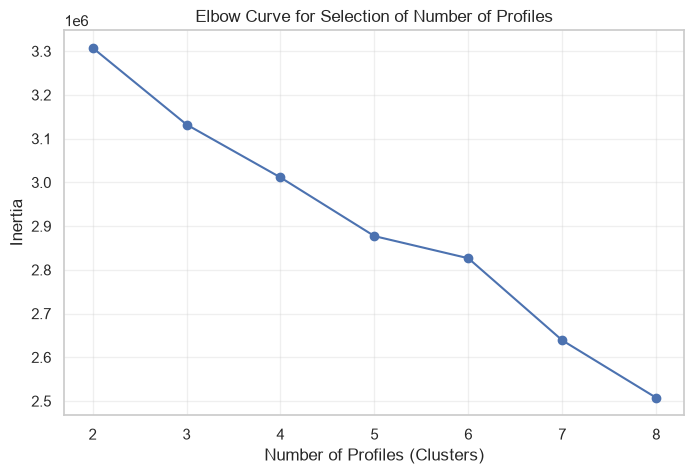

In [30]:
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

cluster_range = range(2, 9)
inertia_values = []

for k in cluster_range:
    mbk = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        n_init=10,
        random_state=42
    )
    
    mbk.fit(X_train_scaled)
    inertia_values.append(mbk.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Profiles (Clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for Selection of Number of Profiles")
plt.xticks(list(cluster_range))
plt.grid(True, alpha=0.3)

plt.show()

Clusters = 2, Silhouette Score = 0.1366
Clusters = 3, Silhouette Score = 0.0570
Clusters = 4, Silhouette Score = 0.0567
Clusters = 5, Silhouette Score = 0.0660
Clusters = 6, Silhouette Score = 0.0823
Clusters = 7, Silhouette Score = 0.0960
Clusters = 8, Silhouette Score = 0.0653


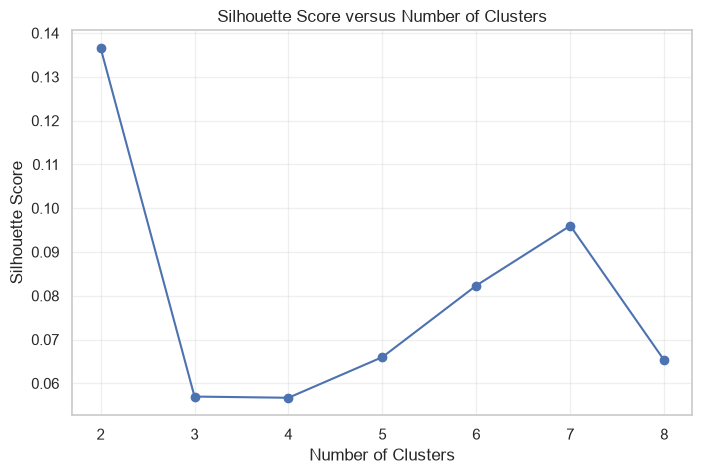

In [31]:
from sklearn.metrics import silhouette_score
import numpy as np

# Use a representative sample for faster computation
SAMPLE_SIZE = 5000

rng = np.random.RandomState(42)

sample_size = min(
    SAMPLE_SIZE,
    X_train_scaled.shape[0]
)

sample_indices = rng.choice(
    X_train_scaled.shape[0],
    size=sample_size,
    replace=False
)

X_cluster_sample = X_train_scaled[sample_indices]

silhouette_scores = []

for k in range(2, 9):

    mbk = MiniBatchKMeans(
        n_clusters=k,
        batch_size=2048,
        n_init=10,
        random_state=42
    )

    sample_labels = mbk.fit_predict(
        X_cluster_sample
    )

    score = silhouette_score(
        X_cluster_sample,
        sample_labels
    )

    silhouette_scores.append(score)

    print(
        f"Clusters = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score versus Number of Clusters")
plt.xticks(range(2, 9))
plt.grid(True, alpha=0.3)

plt.show()

In [32]:
N_CLUSTERS = 4

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=2048,
    n_init=10,
    random_state=42
)

train_profiles = kmeans.fit_predict(
    X_train_scaled
)

val_profiles = kmeans.predict(
    X_val_scaled
)

test_profiles = kmeans.predict(
    X_test_scaled
)

print(
    "Patient profiling completed."
)

print(
    "Number of profiles:",
    N_CLUSTERS
)

Patient profiling completed.
Number of profiles: 4


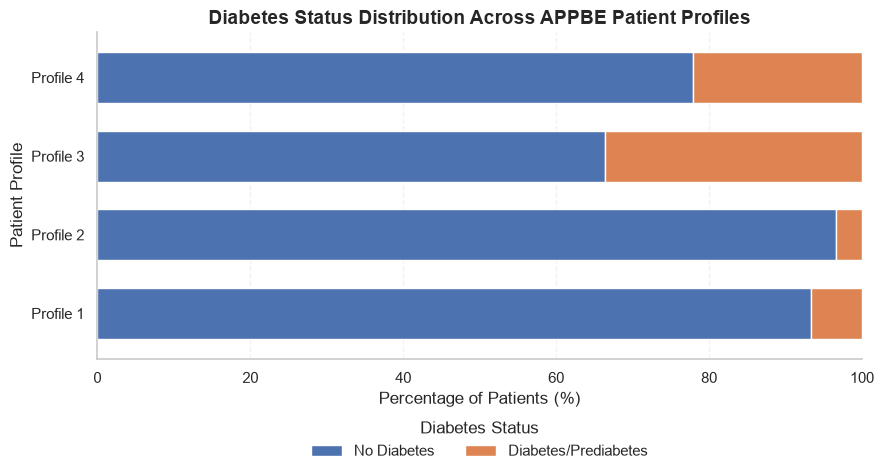

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

profile_diabetes = pd.DataFrame({
    "Profile": train_profiles,
    "Diabetes": y_train.values
})



profile_counts = pd.crosstab(
    profile_diabetes["Profile"],
    profile_diabetes["Diabetes"]
)


profile_counts = profile_counts.reindex(
    columns=[0, 1],
    fill_value=0
)

profile_counts.columns = [
    "No Diabetes",
    "Diabetes/Prediabetes"
]

profile_percent = profile_counts.div(
    profile_counts.sum(axis=1),
    axis=0
) * 100


fig, ax = plt.subplots(figsize=(9, 5))

profile_percent.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    width=0.65
)



ax.set_xlabel("Percentage of Patients (%)", fontsize=12)
ax.set_ylabel("Patient Profile", fontsize=12)

ax.set_title(
    "Diabetes Status Distribution Across APPBE Patient Profiles",
    fontsize=14,
    fontweight="bold"
)


ax.set_yticklabels(
    [f"Profile {i+1}" for i in profile_percent.index]
)


ax.set_xlim(0, 100)


ax.legend(
    title="Diabetes Status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

0    34404
1    64973
2    25616
3    52583
Name: count, dtype: int64

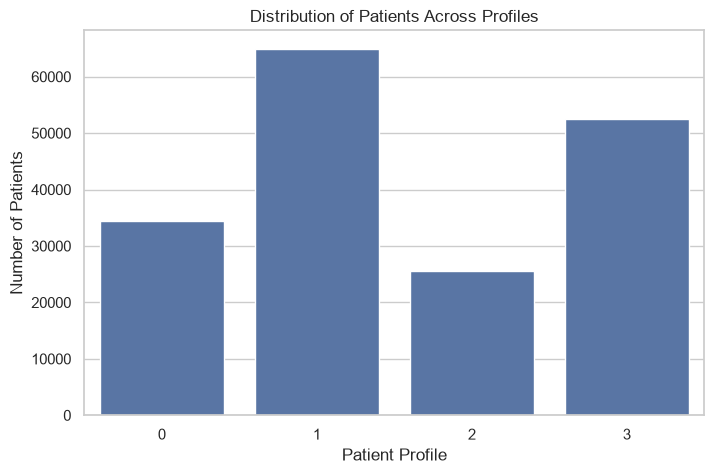

In [34]:
train_profile_counts = pd.Series(
    train_profiles
).value_counts().sort_index()

display(
    train_profile_counts
)

plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    x=train_profile_counts.index,
    y=train_profile_counts.values
)

plt.title(
    "Distribution of Patients Across Profiles"
)

plt.xlabel(
    "Patient Profile"
)

plt.ylabel(
    "Number of Patients"
)
plt.savefig("profile Distribution.; c.png", dpi=600, bbox_inches="tight")
plt.show()

In [35]:


profile_data = X_train.copy()

profile_data["Profile"] = train_profiles

profile_data[
    "Diabetes_binary"
] = y_train.values

print(
    "Profile dataset created."
)

Profile dataset created.


In [36]:
profile_summary = profile_data.groupby(
    "Profile"
).agg(
    Patients=(
        "Diabetes_binary",
        "count"
    ),

    Diabetes_Rate=(
        "Diabetes_binary",
        "mean"
    ),

    Mean_BMI=(
        "BMI",
        "mean"
    ),

    Mean_Age=(
        "Age",
        "mean"
    ),

    HighBP_Rate=(
        "HighBP",
        "mean"
    ),

    HighChol_Rate=(
        "HighChol",
        "mean"
    ),

    Smoker_Rate=(
        "Smoker",
        "mean"
    ),

    PhysicalActivity_Rate=(
        "PhysActivity",
        "mean"
    )
)

percentage_columns = [
    "Diabetes_Rate",
    "HighBP_Rate",
    "HighChol_Rate",
    "Smoker_Rate",
    "PhysicalActivity_Rate"
]

profile_summary[
    percentage_columns
] *= 100

display(
    profile_summary.round(2)
)

,Patients,Diabetes_Rate,Mean_BMI,Mean_Age,HighBP_Rate,HighChol_Rate,Smoker_Rate,PhysicalActivity_Rate
Profile,,,,,,,,
0,34404,6.61,28.79,6.07,18.52,23.20,52.66,65.85
1,64973,3.44,26.18,7.05,10.89,22.29,26.19,92.79
2,25616,33.58,31.36,9.07,69.42,61.48,61.98,44.36
3,52583,22.11,29.37,10.02,85.51,70.61,52.64,76.35


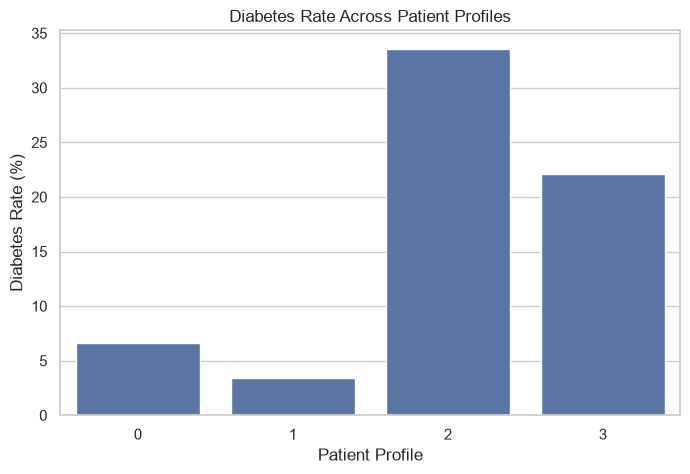

In [37]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    x=profile_summary.index,
    y=profile_summary["Diabetes_Rate"]
)

plt.title(
    "Diabetes Rate Across Patient Profiles"
)

plt.xlabel(
    "Patient Profile"
)

plt.ylabel(
    "Diabetes Rate (%)"
)
plt.savefig("Diabetes Rate by Profile.; c.png", dpi=600, bbox_inches="tight")
plt.show()

In [38]:
profile_visual = profile_summary[
    [
        "Mean_BMI",
        "Mean_Age",
        "HighBP_Rate",
        "HighChol_Rate"
    ]
]

display(
    profile_visual.round(2)
)

,Mean_BMI,Mean_Age,HighBP_Rate,HighChol_Rate
Profile,,,,
0,28.79,6.07,18.52,23.20
1,26.18,7.05,10.89,22.29
2,31.36,9.07,69.42,61.48
3,29.37,10.02,85.51,70.61


# Base Machine Learning Models

Three diverse models are used in the proposed framework.

### Random Forest
A nonlinear bagging-based ensemble classifier.

### Logistic Regression
A linear probabilistic classifier that provides model diversity.

### HistGradientBoosting
A gradient boosting classifier capable of learning nonlinear relationships.

The models are deliberately diverse because different models may perform
better for different patient profiles.

In [39]:
models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            max_depth=14,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ),

    "HistGradientBoosting":
        HistGradientBoostingClassifier(
            max_iter=180,
            learning_rate=0.07,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42
        )
}

print(
    "Three base models created."
)

Three base models created.


In [40]:
trained_models = {}

for model_name, model in models.items():

    print(
        "Training:",
        model_name
    )

    if model_name == "Logistic Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

    else:

        model.fit(
            X_train,
            y_train
        )

    trained_models[
        model_name
    ] = model

print(
    "\nAll models trained successfully."
)

Training: Random Forest
Training: Logistic Regression
Training: HistGradientBoosting

All models trained successfully.


# Overall Model Evaluation

The individual models are evaluated using the independent test set.

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

ROC-AUC is emphasized because the target distribution is not perfectly
balanced.

In [41]:
overall_results = []

for model_name, model in trained_models.items():

    if model_name == "Logistic Regression":

        predictions = model.predict(
            X_test_scaled
        )

        probabilities = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    result = {

        "Model": model_name,

        "Accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "Precision":
            precision_score(
                y_test,
                predictions
            ),

        "Recall":
            recall_score(
                y_test,
                predictions
            ),

        "F1-Score":
            f1_score(
                y_test,
                predictions
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                probabilities
            )
    }

    overall_results.append(
        result
    )

overall_df = pd.DataFrame(
    overall_results
)

display(
    overall_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.7475,0.3239,0.7469,0.4518,0.8267
1,Logistic Regression,0.7334,0.3129,0.7633,0.4438,0.8216
2,HistGradientBoosting,0.8666,0.5758,0.1605,0.2510,0.8297


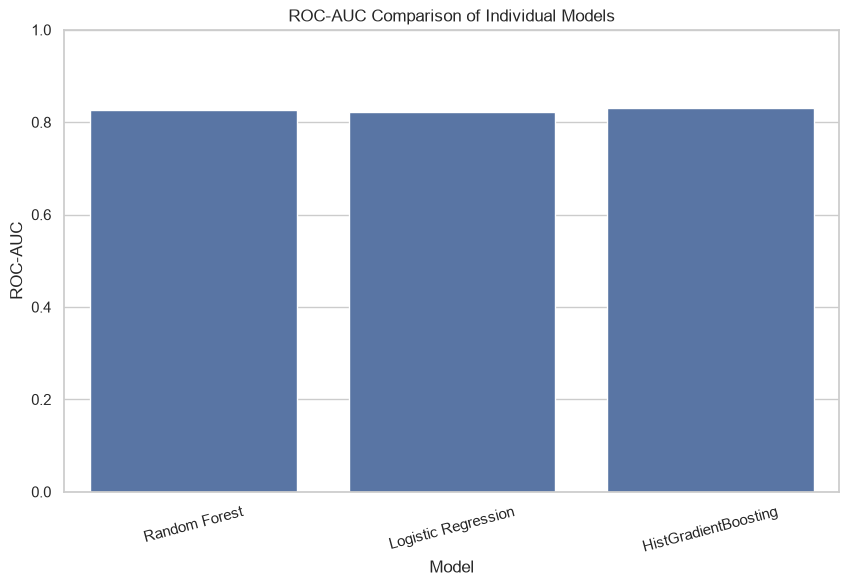

In [42]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=overall_df,
    x="Model",
    y="ROC-AUC"
)

plt.ylim(
    0,
    1
)

plt.title(
    "ROC-AUC Comparison of Individual Models"
)

plt.xticks(
    rotation=15
)
plt.savefig("Overall Model Perfomance Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# Profile-Specific Model Evaluation

This is the central component of the proposed APPBE method.

Instead of assuming that every model performs equally well for every
patient, each model is evaluated separately within each patient profile.

Validation-set ROC-AUC is used to estimate the performance of each base
learner for each profile.

In [43]:
profile_results = []

for profile in sorted(
    np.unique(val_profiles)
):

    profile_mask = (
        val_profiles == profile
    )

    y_profile = y_val.iloc[
        profile_mask
    ]

    print(
        f"\nProfile {profile}"
    )

    print(
        "Number of patients:",
        profile_mask.sum()
    )

    for model_name, model in trained_models.items():

        if model_name == "Logistic Regression":

            X_profile = X_val_scaled[
                profile_mask
            ]

        else:

            X_profile = X_val.iloc[
                profile_mask
            ]

        predictions = model.predict(
            X_profile
        )

        probabilities = model.predict_proba(
            X_profile
        )[:, 1]

        auc_score = roc_auc_score(
            y_profile,
            probabilities
        )

        f1 = f1_score(
            y_profile,
            predictions
        )

        profile_results.append({

            "Profile": profile,

            "Model": model_name,

            "ROC-AUC": auc_score,

            "F1-Score": f1
        })

profile_results_df = pd.DataFrame(
    profile_results
)

display(
    profile_results_df.round(4)
)


Profile 0
Number of patients: 7421

Profile 1
Number of patients: 13843

Profile 2
Number of patients: 5429

Profile 3
Number of patients: 11359


,Profile,Model,ROC-AUC,F1-Score
0,0,Random Forest,0.8003,0.3026
1,0,Logistic Regression,0.8025,0.3019
2,0,HistGradientBoosting,0.8096,0.0187
3,1,Random Forest,0.7736,0.1297
4,1,Logistic Regression,0.7736,0.0854
5,1,HistGradientBoosting,0.7825,0.0000
6,2,Random Forest,0.7173,0.5483
7,2,Logistic Regression,0.7125,0.5369
8,2,HistGradientBoosting,0.7288,0.4342
9,3,Random Forest,0.6938,0.4286


In [44]:
profile_auc_table = profile_results_df.pivot(
    index="Profile",
    columns="Model",
    values="ROC-AUC"
)

print(
    "Profile-specific ROC-AUC:"
)

display(
    profile_auc_table.round(4)
)

Profile-specific ROC-AUC:


Model,HistGradientBoosting,Logistic Regression,Random Forest
Profile,,,
0,0.8096,0.8025,0.8003
1,0.7825,0.7736,0.7736
2,0.7288,0.7125,0.7173
3,0.6996,0.6857,0.6938


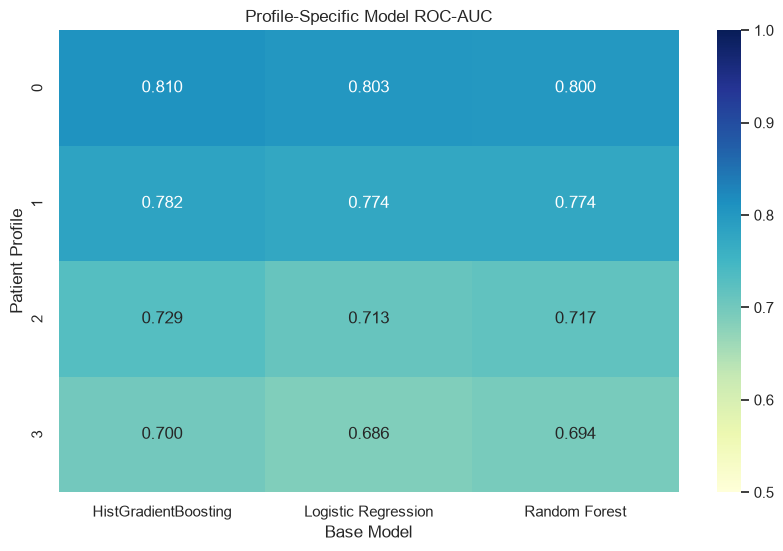

In [45]:
plt.figure(
    figsize=(10, 6)
)

sns.heatmap(
    profile_auc_table,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0.5,
    vmax=1
)

plt.title(
    "Profile-Specific Model ROC-AUC"
)

plt.xlabel(
    "Base Model"
)

plt.ylabel(
    "Patient Profile"
)
plt.savefig("Profile Performance Heatmap.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# Adaptive Weight Generation

The profile-specific validation performance is converted into adaptive
model weights.

For every patient profile:

1. ROC-AUC values are obtained for all three models.
2. The performance above random discrimination is considered.
3. The scores are normalized.
4. The resulting values become the adaptive ensemble weights.

Thus, APPBE does not use the same weights for all patients.

In [46]:
adaptive_weights = profile_auc_table.copy()

for profile in adaptive_weights.index:

    scores = adaptive_weights.loc[
        profile
    ].values.astype(float)

    adjusted_scores = np.maximum(
        scores - 0.50,
        0.001
    )

    normalized_weights = (
        adjusted_scores /
        adjusted_scores.sum()
    )

    adaptive_weights.loc[
        profile
    ] = normalized_weights

print(
    "APPBE Adaptive Weights:"
)

display(
    adaptive_weights.round(4)
)

APPBE Adaptive Weights:


Model,HistGradientBoosting,Logistic Regression,Random Forest
Profile,,,
0,0.3394,0.3316,0.3291
1,0.3404,0.3298,0.3298
2,0.3474,0.3226,0.3300
3,0.3447,0.3207,0.3346


In [47]:
weight_sums = adaptive_weights.sum(
    axis=1
)

print(
    "Weight sums for each profile:"
)

display(
    weight_sums.round(4)
)

Weight sums for each profile:


Profile
0    1.0
1    1.0
2    1.0
3    1.0
dtype: float64

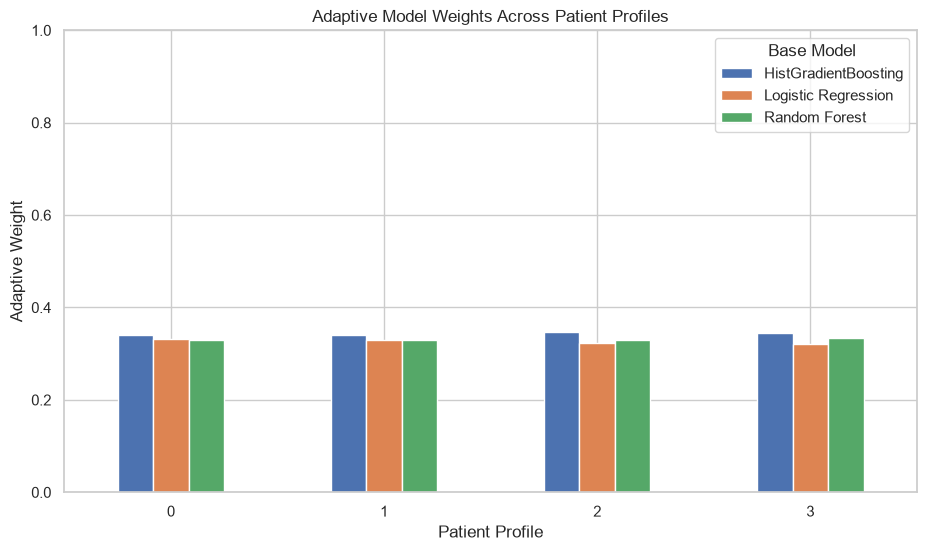

In [48]:
adaptive_weights.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Adaptive Model Weights Across Patient Profiles"
)

plt.xlabel(
    "Patient Profile"
)

plt.ylabel(
    "Adaptive Weight"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Base Model"
)
plt.savefig("Adaptive Weight Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# APPBE Adaptive Ensemble Prediction

For every test patient:

1. The patient's profile is identified.
2. Each base model generates a diabetes probability.
3. The corresponding profile-specific weights are obtained.
4. Model probabilities are multiplied by their adaptive weights.
5. The weighted probabilities are summed.
6. The final APPBE probability is converted into a binary prediction.

This patient-specific weighting mechanism represents the main novelty of
the proposed framework.

In [49]:
test_probabilities = {}

for model_name, model in trained_models.items():

    if model_name == "Logistic Regression":

        probabilities = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    test_probabilities[
        model_name
    ] = probabilities

print(
    "Test probabilities generated."
)

Test probabilities generated.


In [50]:
model_names = list(
    trained_models.keys()
)

appbe_probability = np.zeros(
    len(X_test)
)

for i in range(
    len(X_test)
):

    patient_profile = test_profiles[i]

    for model_name in model_names:

        weight = adaptive_weights.loc[
            patient_profile,
            model_name
        ]

        appbe_probability[i] += (
            weight *
            test_probabilities[
                model_name
            ][i]
        )

appbe_prediction = (
    appbe_probability >= 0.50
).astype(int)

print(
    "APPBE prediction completed."
)

APPBE prediction completed.


In [51]:
appbe_result = {

    "Model": "APPBE",

    "Accuracy":
        accuracy_score(
            y_test,
            appbe_prediction
        ),

    "Precision":
        precision_score(
            y_test,
            appbe_prediction
        ),

    "Recall":
        recall_score(
            y_test,
            appbe_prediction
        ),

    "F1-Score":
        f1_score(
            y_test,
            appbe_prediction
        ),

    "ROC-AUC":
        roc_auc_score(
            y_test,
            appbe_probability
        )
}

appbe_df = pd.DataFrame([
    appbe_result
])

display(
    appbe_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,APPBE,0.8131,0.3862,0.5794,0.4635,0.8286


# Final Model Comparison

APPBE is compared against all individual base learners.

The purpose of this comparison is to determine whether patient-profile
based adaptive weighting provides additional predictive value.

In [52]:
final_comparison = pd.concat(
    [
        overall_df,
        appbe_df
    ],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

display(
    final_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,HistGradientBoosting,0.8666,0.5758,0.1605,0.2510,0.8297
3,APPBE,0.8131,0.3862,0.5794,0.4635,0.8286
0,Random Forest,0.7475,0.3239,0.7469,0.4518,0.8267
1,Logistic Regression,0.7334,0.3129,0.7633,0.4438,0.8216


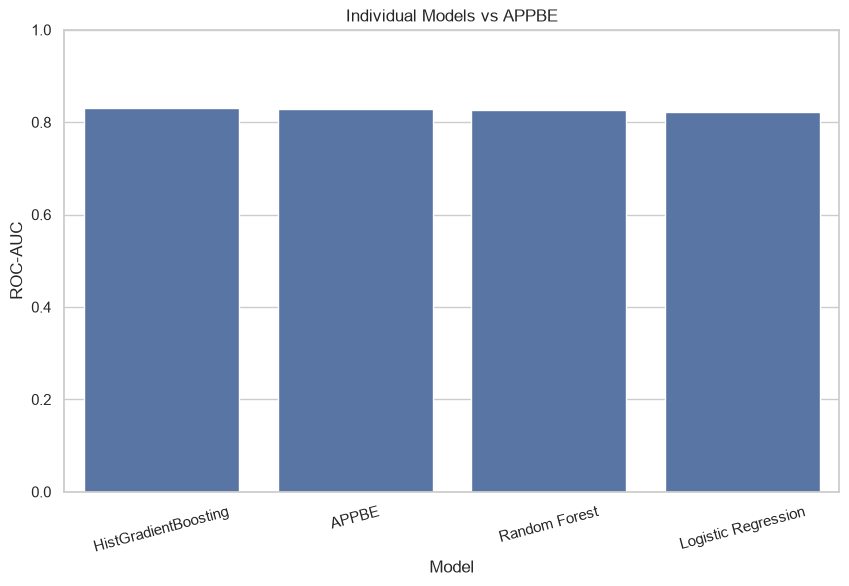

In [53]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=final_comparison,
    x="Model",
    y="ROC-AUC"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Individual Models vs APPBE"
)

plt.xticks(
    rotation=15
)
plt.savefig("Final ROC-AUC Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# ROC Curve Analysis

ROC curves are generated to compare the discrimination capability of the
three individual models and the proposed APPBE framework.

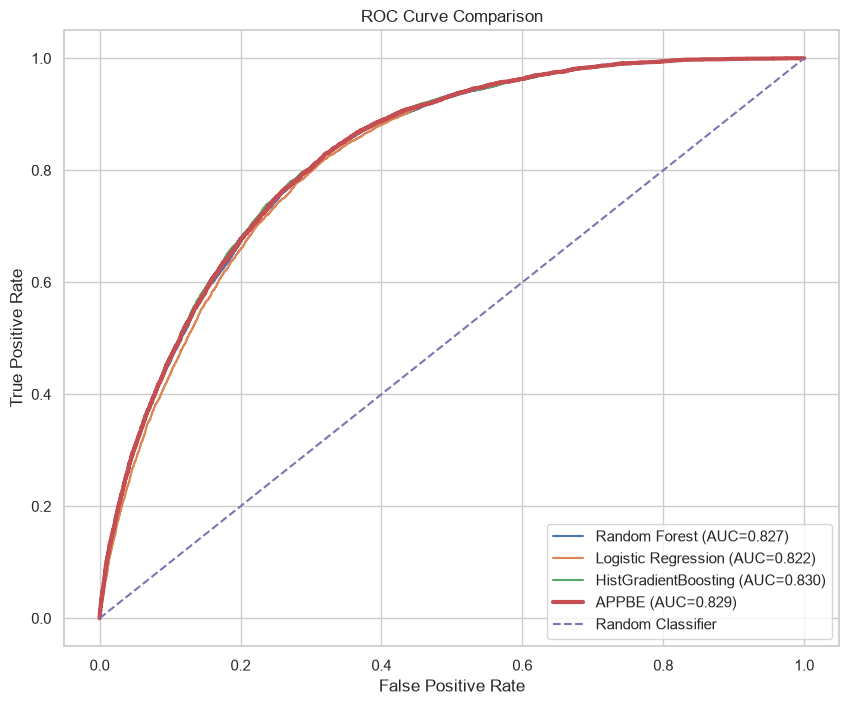

In [54]:
plt.figure(
    figsize=(10, 8)
)

for model_name, model in trained_models.items():

    if model_name == "Logistic Regression":

        probabilities = model.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{model_name} "
            f"(AUC={auc_value:.3f})"
        )
    )

# APPBE ROC
appbe_fpr, appbe_tpr, _ = roc_curve(
    y_test,
    appbe_probability
)

appbe_auc = roc_auc_score(
    y_test,
    appbe_probability
)

plt.plot(
    appbe_fpr,
    appbe_tpr,
    linewidth=3,
    label=(
        f"APPBE "
        f"(AUC={appbe_auc:.3f})"
    )
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()
plt.savefig("ROC Curves.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# APPBE Confusion Matrix

The confusion matrix shows:

- True Negatives
- False Positives
- False Negatives
- True Positives

It provides a detailed view of APPBE classification performance.

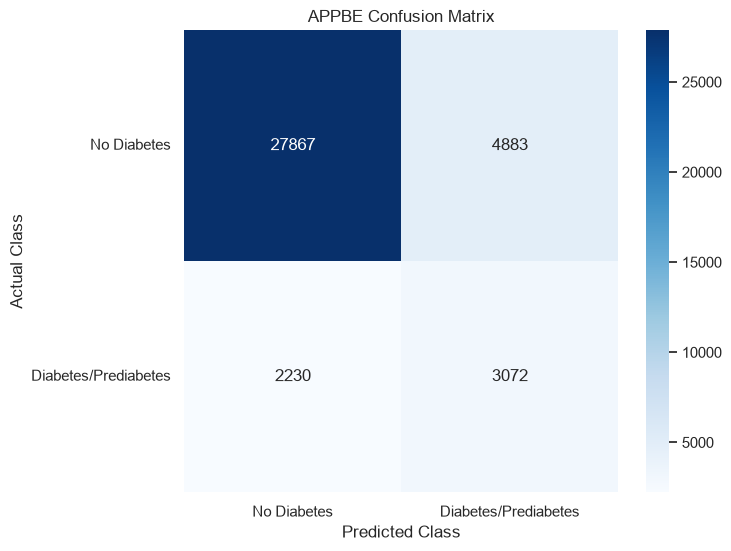

In [55]:
cm = confusion_matrix(
    y_test,
    appbe_prediction
)

plt.figure(
    figsize=(7, 6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "APPBE Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0.5, 1.5],
    ["No Diabetes", "Diabetes/Prediabetes"]
)

plt.yticks(
    [0.5, 1.5],
    ["No Diabetes", "Diabetes/Prediabetes"],
    rotation=0
)
plt.savefig("APPBE Prediction.; c.png", dpi=600, bbox_inches="tight")
plt.show()

In [56]:
print(
    "APPBE Classification Report"
)

print(
    "=" * 60
)

print(
    classification_report(
        y_test,
        appbe_prediction,
        target_names=[
            "No Diabetes",
            "Diabetes/Prediabetes"
        ]
    )
)

APPBE Classification Report
                      precision    recall  f1-score   support

         No Diabetes       0.93      0.85      0.89     32750
Diabetes/Prediabetes       0.39      0.58      0.46      5302

            accuracy                           0.81     38052
           macro avg       0.66      0.72      0.68     38052
        weighted avg       0.85      0.81      0.83     38052



# Explainable AI Using Permutation Importance

Permutation importance is used as the explainability component.

It measures how much model performance decreases when the values of an
individual feature are randomly shuffled.

A larger decrease indicates that the feature contributes more strongly
to the model's predictive performance.

This provides an interpretable ranking of important diabetes indicators.

In [57]:
best_model_name = (
    overall_df
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best individual model:",
    best_model_name
)

Best individual model: HistGradientBoosting


In [58]:
best_model = trained_models[
    best_model_name
]

if best_model_name == "Logistic Regression":

    permutation_result = permutation_importance(
        best_model,
        X_test_scaled,
        y_test,
        n_repeats=5,
        random_state=42,
        scoring="roc_auc"
    )

else:

    permutation_result = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        scoring="roc_auc"
    )

importance_df = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        permutation_result.importances_mean,

    "Std":
        permutation_result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.head(20).round(5)
)

,Feature,Importance,Std
13,GenHlth,0.05069,0.00078
3,BMI,0.03833,0.00103
18,Age,0.03260,0.00159
0,HighBP,0.01676,0.00071
1,HighChol,0.01181,0.00034
2,CholCheck,0.00510,0.00049
10,HvyAlcoholConsump,0.00430,0.00037
17,Sex,0.00298,0.00042
20,Income,0.00235,0.00029
6,HeartDiseaseorAttack,0.00210,0.00036


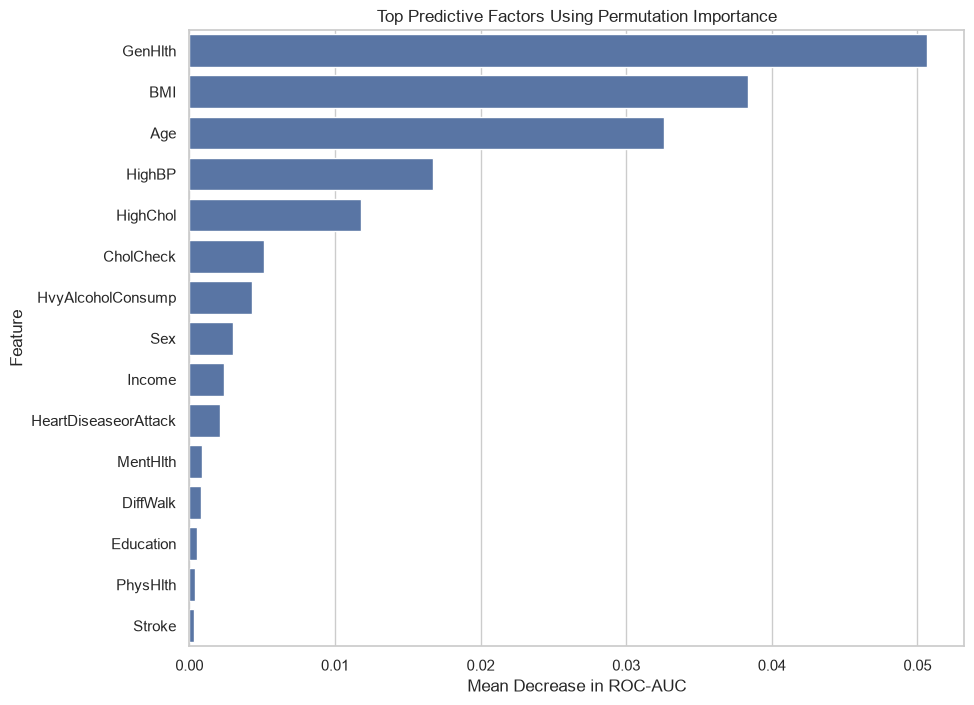

In [77]:
top_features = importance_df.head(
    15
)

plt.figure(
    figsize=(10, 8)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Predictive Factors Using Permutation Importance"
)

plt.xlabel(
    "Mean Decrease in ROC-AUC"
)

plt.ylabel(
    "Feature"
)
plt.savefig("Feature Importance Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# Ablation Study

The ablation study investigates the contribution of the proposed
patient-profile adaptive weighting mechanism.

Two approaches are compared:

### Conventional Equal-Weight Ensemble

All three models receive identical weights:

Random Forest = 1/3
Logistic Regression = 1/3
HistGradientBoosting = 1/3

### APPBE Adaptive Ensemble

The model weights depend on the patient's automatically identified profile.

This experiment directly evaluates whether adaptive patient profiling
contributes to the ensemble performance.

In [60]:
equal_probability = (
    test_probabilities[
        "Random Forest"
    ]

    +

    test_probabilities[
        "Logistic Regression"
    ]

    +

    test_probabilities[
        "HistGradientBoosting"
    ]
) / 3

equal_prediction = (
    equal_probability >= 0.50
).astype(int)

equal_result = {

    "Method":
        "Equal-Weight Ensemble",

    "Accuracy":
        accuracy_score(
            y_test,
            equal_prediction
        ),

    "Precision":
        precision_score(
            y_test,
            equal_prediction
        ),

    "Recall":
        recall_score(
            y_test,
            equal_prediction
        ),

    "F1-Score":
        f1_score(
            y_test,
            equal_prediction
        ),

    "ROC-AUC":
        roc_auc_score(
            y_test,
            equal_probability
        )
}

appbe_ablation_result = {

    "Method":
        "APPBE Adaptive Ensemble",

    "Accuracy":
        accuracy_score(
            y_test,
            appbe_prediction
        ),

    "Precision":
        precision_score(
            y_test,
            appbe_prediction
        ),

    "Recall":
        recall_score(
            y_test,
            appbe_prediction
        ),

    "F1-Score":
        f1_score(
            y_test,
            appbe_prediction
        ),

    "ROC-AUC":
        roc_auc_score(
            y_test,
            appbe_probability
        )
}

ablation_df = pd.DataFrame([
    equal_result,
    appbe_ablation_result
])

display(
    ablation_df.round(4)
)

,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Equal-Weight Ensemble,0.8118,0.3854,0.5898,0.4662,0.8286
1,APPBE Adaptive Ensemble,0.8131,0.3862,0.5794,0.4635,0.8286


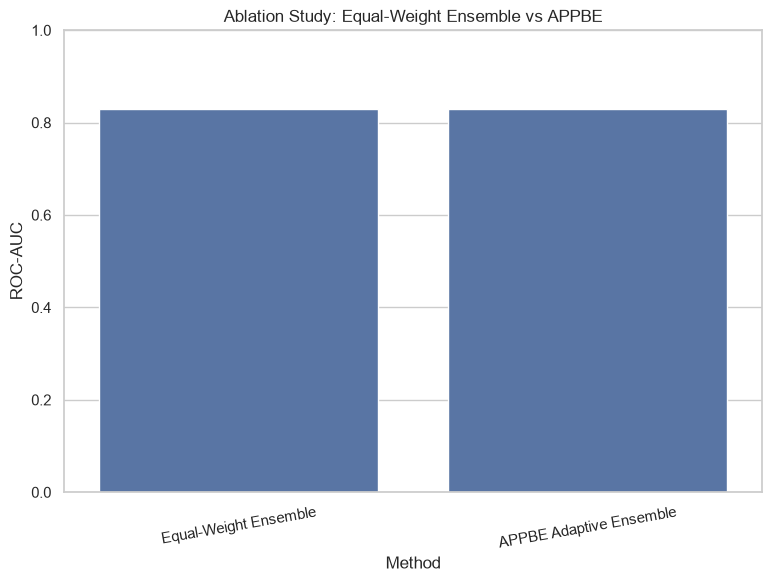

In [61]:
plt.figure(
    figsize=(9, 6)
)

sns.barplot(
    data=ablation_df,
    x="Method",
    y="ROC-AUC"
)

plt.ylim(
    0,
    1
)

plt.title(
    "Ablation Study: Equal-Weight Ensemble vs APPBE"
)

plt.xticks(
    rotation=10
)
plt.savefig("Ablation ROC-AUC Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# Profile-Wise APPBE Performance

The final APPBE model is evaluated separately for each patient profile.

This analysis helps determine whether the adaptive ensemble maintains
useful predictive performance across heterogeneous patient groups.

In [62]:
profile_appbe_results = []

for profile in sorted(
    np.unique(test_profiles)
):

    mask = (
        test_profiles == profile
    )

    if mask.sum() < 10:

        continue

    y_profile = y_test.iloc[
        mask
    ]

    probability_profile = (
        appbe_probability[mask]
    )

    prediction_profile = (
        appbe_prediction[mask]
    )

    profile_appbe_results.append({

        "Profile":
            profile,

        "Patients":
            mask.sum(),

        "Accuracy":
            accuracy_score(
                y_profile,
                prediction_profile
            ),

        "Precision":
            precision_score(
                y_profile,
                prediction_profile
            ),

        "Recall":
            recall_score(
                y_profile,
                prediction_profile
            ),

        "F1-Score":
            f1_score(
                y_profile,
                prediction_profile
            ),

        "ROC-AUC":
            roc_auc_score(
                y_profile,
                probability_profile
            )
    })

profile_appbe_df = pd.DataFrame(
    profile_appbe_results
)

display(
    profile_appbe_df.round(4)
)

,Profile,Patients,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,0,7446,0.9210,0.3431,0.1598,0.2181,0.8019
1,1,13875,0.9643,0.2857,0.0082,0.0159,0.8002
2,2,5444,0.5817,0.4348,0.8368,0.5722,0.7191
3,3,11287,0.6675,0.3484,0.5899,0.4381,0.6997


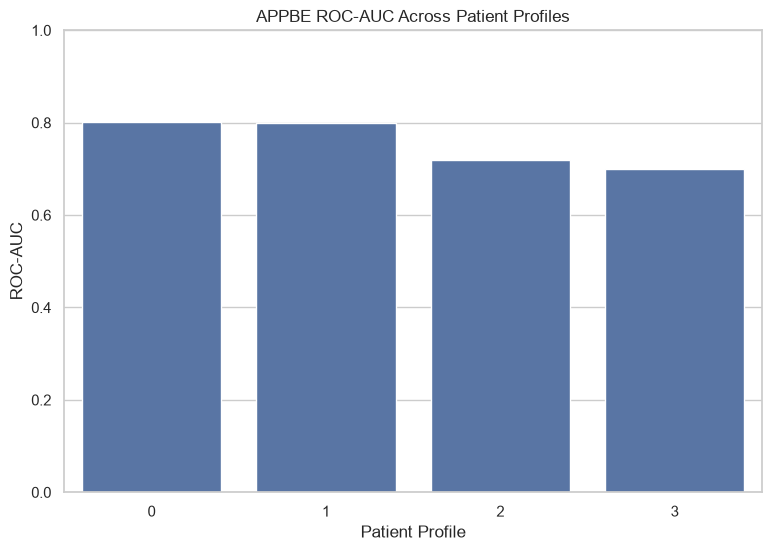

In [63]:
plt.figure(
    figsize=(9, 6)
)

sns.barplot(
    data=profile_appbe_df,
    x="Profile",
    y="ROC-AUC"
)

plt.ylim(
    0,
    1
)

plt.title(
    "APPBE ROC-AUC Across Patient Profiles"
)

plt.xlabel(
    "Patient Profile"
)

plt.ylabel(
    "ROC-AUC"
)
plt.savefig("Profile-wise ROC-AUC Graph.; c.png", dpi=600, bbox_inches="tight")
plt.show()

# Individual Patient Risk Prediction

The following demonstration shows how APPBE generates a prediction for
an individual patient.

The system first identifies the patient's profile and then combines the
three model probabilities using the adaptive weights corresponding to
that profile.

In [64]:
new_patient = X_test.iloc[[0]].copy()

print(
    "Example Patient:"
)

display(
    new_patient
)

Example Patient:


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
15722,1,1,1,26,0,0,0,1,1,1,...,1,0,3,30,0,1,0,8,6,5


In [65]:
new_patient_scaled = scaler.transform(
    new_patient
)

new_profile = kmeans.predict(
    new_patient_scaled
)[0]

print(
    "Identified Patient Profile:",
    new_profile
)

Identified Patient Profile: 2


In [66]:
new_predictions = {}

for model_name, model in trained_models.items():

    if model_name == "Logistic Regression":

        probability = model.predict_proba(
            new_patient_scaled
        )[0, 1]

    else:

        probability = model.predict_proba(
            new_patient
        )[0, 1]

    new_predictions[
        model_name
    ] = probability

print(
    "Individual Model Probabilities"
)

print(
    "=" * 50
)

for model_name, probability in new_predictions.items():

    print(
        f"{model_name:25s}: "
        f"{probability:.4f}"
    )

Individual Model Probabilities
Random Forest            : 0.5844
Logistic Regression      : 0.5324
HistGradientBoosting     : 0.1778


In [67]:
patient_weights = adaptive_weights.loc[
    new_profile
]

print(
    "Adaptive weights for Patient Profile",
    new_profile
)

display(
    patient_weights.round(4)
)

Adaptive weights for Patient Profile 2


Model
HistGradientBoosting    0.3474
Logistic Regression     0.3226
Random Forest           0.3300
Name: 2, dtype: float64

In [68]:
new_appbe_probability = 0

for model_name in model_names:

    weight = adaptive_weights.loc[
        new_profile,
        model_name
    ]

    new_appbe_probability += (
        weight *
        new_predictions[
            model_name
        ]
    )

print(
    "Patient Profile:",
    new_profile
)

print(
    "APPBE Risk Probability:",
    round(
        new_appbe_probability,
        4
    )
)

if new_appbe_probability >= 0.50:

    print(
        "Prediction: HIGHER DIABETES RISK"
    )

else:

    print(
        "Prediction: LOWER DIABETES RISK"
    )

Patient Profile: 2
APPBE Risk Probability: 0.4264
Prediction: LOWER DIABETES RISK


# Saving Experimental Results

The important experimental outputs are saved as CSV files.

These files can be used to prepare:

- Thesis result tables
- Research paper tables
- Graphs
- Performance comparisons
- Ablation study results
- Patient profile analysis

In [69]:
overall_df.to_csv(
    "APPBE_Individual_Model_Results.csv",
    index=False
)

final_comparison.to_csv(
    "APPBE_Final_Model_Comparison.csv",
    index=False
)

profile_summary.to_csv(
    "APPBE_Patient_Profile_Summary.csv"
)

profile_auc_table.to_csv(
    "APPBE_Profile_Model_Performance.csv"
)

adaptive_weights.to_csv(
    "APPBE_Adaptive_Weights.csv"
)

ablation_df.to_csv(
    "APPBE_Ablation_Study.csv",
    index=False
)

profile_appbe_df.to_csv(
    "APPBE_Profile_Wise_Performance.csv",
    index=False
)

importance_df.to_csv(
    "APPBE_Feature_Importance.csv",
    index=False
)

print(
    "All result files saved successfully."
)

All result files saved successfully.


# Final Experimental Summary

The proposed APPBE framework integrates patient profiling, ensemble
learning and explainability for early diabetes risk prediction.

## Dataset

UCI CDC Diabetes Health Indicators Dataset

## Patient Profiling

MiniBatchKMeans is used to automatically identify heterogeneous patient
profiles.

## Base Models

1. Random Forest
2. Logistic Regression
3. HistGradientBoosting

## Proposed APPBE Mechanism

Profile-specific validation performance is used to calculate adaptive
weights for the three base learners.

## Explainability

Permutation Importance is used to identify the most influential
predictive health and lifestyle indicators.

## Evaluation

The framework is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- ROC Curves

## Ablation Study

APPBE is compared against a conventional equal-weight ensemble to
evaluate the contribution of patient-profile-based adaptive weighting.

The final performance values should be reported exactly as obtained from
the independent test set.

APPBE ERROR ANALYSIS
Total test cases       : 38052
Correct predictions    : 30939
Incorrect predictions  : 7113
False positives        : 4883
False negatives        : 2230
Error rate (%)         : 18.69


,Prediction Type,Count,Percentage
0,True Negative,27867,73.23
1,False Positive,4883,12.83
2,True Positive,3072,8.07
3,False Negative,2230,5.86


,Patients,Errors,False_Positives,False_Negatives,Error_Rate_%
Profile,,,,,
0,7446,588,157,431,7.90
1,13875,495,10,485,3.57
2,5444,2277,1980,297,41.83
3,11287,3753,2736,1017,33.25


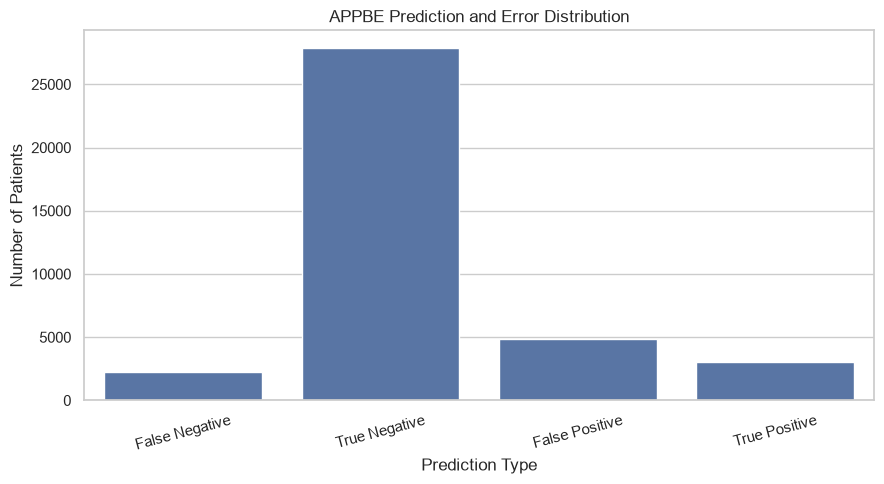

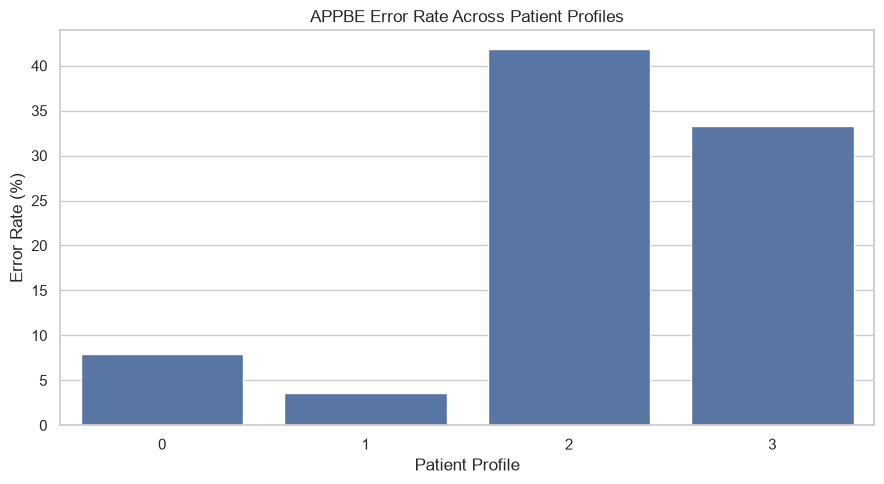

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



error_df = X_test.copy()

error_df["Actual"] = np.asarray(y_test)
error_df["Predicted"] = np.asarray(appbe_prediction)
error_df["Probability"] = np.asarray(appbe_probability)
error_df["Profile"] = np.asarray(test_profiles)

# Prediction type
error_df["Prediction_Type"] = np.select(
    [
        (error_df["Actual"] == 1) & (error_df["Predicted"] == 1),
        (error_df["Actual"] == 0) & (error_df["Predicted"] == 0),
        (error_df["Actual"] == 0) & (error_df["Predicted"] == 1),
        (error_df["Actual"] == 1) & (error_df["Predicted"] == 0)
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

error_df["Correct"] = (
    error_df["Actual"] == error_df["Predicted"]
)


error_df["Confidence"] = np.maximum(
    error_df["Probability"],
    1 - error_df["Probability"]
)



total = len(error_df)
correct = error_df["Correct"].sum()
errors = total - correct

fp = ((error_df["Actual"] == 0) &
      (error_df["Predicted"] == 1)).sum()

fn = ((error_df["Actual"] == 1) &
      (error_df["Predicted"] == 0)).sum()

print("=" * 65)
print("APPBE ERROR ANALYSIS")
print("=" * 65)
print(f"Total test cases       : {total}")
print(f"Correct predictions    : {correct}")
print(f"Incorrect predictions  : {errors}")
print(f"False positives        : {fp}")
print(f"False negatives        : {fn}")
print(f"Error rate (%)         : {(errors/total)*100:.2f}")
print("=" * 65)



error_summary = (
    error_df["Prediction_Type"]
    .value_counts()
    .rename_axis("Prediction Type")
    .reset_index(name="Count")
)

error_summary["Percentage"] = (
    error_summary["Count"] / total * 100
)

display(error_summary.round(2))

profile_analysis = (
    error_df
    .groupby("Profile")
    .agg(
        Patients=("Actual", "count"),
        Errors=("Correct", lambda x: (~x).sum()),
        False_Positives=(
            "Prediction_Type",
            lambda x: (x == "False Positive").sum()
        ),
        False_Negatives=(
            "Prediction_Type",
            lambda x: (x == "False Negative").sum()
        )
    )
)

profile_analysis["Error_Rate_%"] = (
    profile_analysis["Errors"] /
    profile_analysis["Patients"] * 100
)

display(profile_analysis.round(2))



plt.figure(figsize=(9, 5))

sns.countplot(
    data=error_df,
    x="Prediction_Type"
)

plt.title("APPBE Prediction and Error Distribution")
plt.xlabel("Prediction Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))

sns.barplot(
    x=profile_analysis.index.astype(str),
    y=profile_analysis["Error_Rate_%"]
)

plt.title("APPBE Error Rate Across Patient Profiles")
plt.xlabel("Patient Profile")
plt.ylabel("Error Rate (%)")
plt.tight_layout()
plt.show()

DETAILED APPBE ERROR ANALYSIS
False Positive cases       : 4883
False Negative cases       : 2230
High-confidence errors     : 501
Uncertain predictions      : 3622

Average characteristics of correct and incorrect predictions:


,Incorrect,Correct
BMI,31.55,27.65
Age,9.56,7.65
HighBP,0.78,0.34
HighChol,0.67,0.37
Smoker,0.53,0.42
PhysActivity,0.63,0.78
GenHlth,3.28,2.33
MentHlth,4.12,2.98
PhysHlth,7.41,3.50



Characteristics of False Positives and False Negatives:


Prediction_Type,False Negative,False Positive
BMI,28.81,32.80
Age,8.84,9.89
HighBP,0.52,0.90
HighChol,0.49,0.76
Smoker,0.48,0.55
PhysActivity,0.74,0.59
GenHlth,2.69,3.54
MentHlth,2.91,4.67
PhysHlth,4.24,8.86


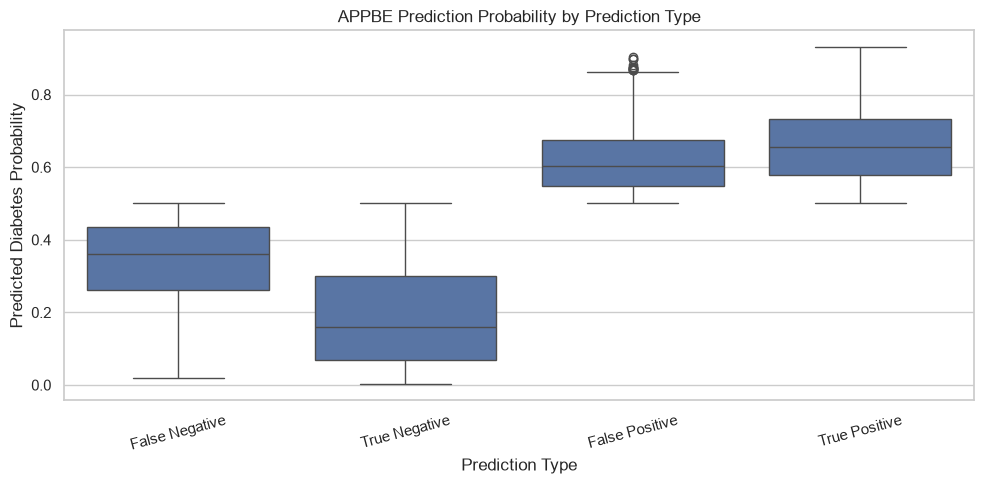

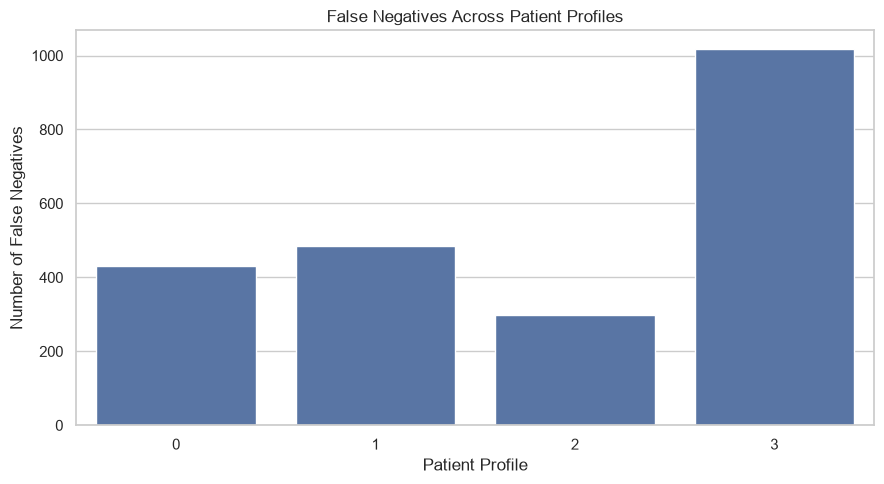


FINAL ERROR ANALYSIS FINDINGS
Profile with highest error rate : 2
Highest profile error rate      : 41.83%
False positives                 : 4883
False negatives                 : 2230
High-confidence errors          : 501

Research interpretation:
The error analysis examines whether APPBE errors are distributed uniformly across patient profiles.
Profile-wise error rates help identify patient groups that are more difficult to classify.
False-negative cases are examined separately because missing a higher-risk patient is important in early diabetes risk prediction.
High-confidence errors and predictions close to the decision threshold provide additional information about difficult classification cases.

This analysis will be considered together with the overall model comparison and ablation study.


In [71]:


false_positive_cases = error_df[
    error_df["Prediction_Type"] == "False Positive"
].copy()

false_negative_cases = error_df[
    error_df["Prediction_Type"] == "False Negative"
].copy()



high_confidence_errors = error_df[
    (error_df["Correct"] == False) &
    (error_df["Confidence"] >= 0.80)
].copy()


uncertain_cases = error_df[
    abs(error_df["Probability"] - 0.50) <= 0.05
].copy()

print("=" * 65)
print("DETAILED APPBE ERROR ANALYSIS")
print("=" * 65)

print(
    f"False Positive cases       : {len(false_positive_cases)}"
)

print(
    f"False Negative cases       : {len(false_negative_cases)}"
)

print(
    f"High-confidence errors     : {len(high_confidence_errors)}"
)

print(
    f"Uncertain predictions      : {len(uncertain_cases)}"
)

print("=" * 65)



possible_features = [
    "BMI",
    "Age",
    "HighBP",
    "HighChol",
    "Smoker",
    "PhysActivity",
    "GenHlth",
    "MentHlth",
    "PhysHlth"
]

available_features = [
    f for f in possible_features
    if f in error_df.columns
]

if len(available_features) > 0:

    error_characteristics = (
        error_df
        .groupby("Correct")[available_features]
        .mean()
        .T
    )

    error_characteristics.columns = [
        "Incorrect" if c == False else "Correct"
        for c in error_characteristics.columns
    ]

    print("\nAverage characteristics of correct and incorrect predictions:")
    display(error_characteristics.round(2))



if len(available_features) > 0:

    error_type_characteristics = (
        error_df[
            error_df["Prediction_Type"].isin(
                ["False Positive", "False Negative"]
            )
        ]
        .groupby("Prediction_Type")[available_features]
        .mean()
        .T
    )

    print("\nCharacteristics of False Positives and False Negatives:")
    display(error_type_characteristics.round(2))


plt.figure(figsize=(10, 5))

sns.boxplot(
    data=error_df,
    x="Prediction_Type",
    y="Probability"
)

plt.title(
    "APPBE Prediction Probability by Prediction Type"
)

plt.xlabel("Prediction Type")
plt.ylabel("Predicted Diabetes Probability")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



fn_profile = (
    false_negative_cases
    .groupby("Profile")
    .size()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=fn_profile.index.astype(str),
    y=fn_profile.values
)

plt.title(
    "False Negatives Across Patient Profiles"
)

plt.xlabel("Patient Profile")
plt.ylabel("Number of False Negatives")
plt.tight_layout()
plt.show()


highest_error_profile = profile_analysis[
    "Error_Rate_%"
].idxmax()

highest_error_rate = profile_analysis.loc[
    highest_error_profile,
    "Error_Rate_%"
]

print("\n" + "=" * 65)
print("FINAL ERROR ANALYSIS FINDINGS")
print("=" * 65)

print(
    f"Profile with highest error rate : "
    f"{highest_error_profile}"
)

print(
    f"Highest profile error rate      : "
    f"{highest_error_rate:.2f}%"
)

print(
    f"False positives                 : {fp}"
)

print(
    f"False negatives                 : {fn}"
)

print(
    f"High-confidence errors          : "
    f"{len(high_confidence_errors)}"
)

print("=" * 65)

print("\nResearch interpretation:")

print(
    "The error analysis examines whether APPBE errors are "
    "distributed uniformly across patient profiles."
)

print(
    "Profile-wise error rates help identify patient groups "
    "that are more difficult to classify."
)

print(
    "False-negative cases are examined separately because "
    "missing a higher-risk patient is important in early "
    "diabetes risk prediction."
)

print(
    "High-confidence errors and predictions close to the "
    "decision threshold provide additional information "
    "about difficult classification cases."
)

print(
    "\nThis analysis will be considered together with the "
    "overall model comparison and ablation study."
)

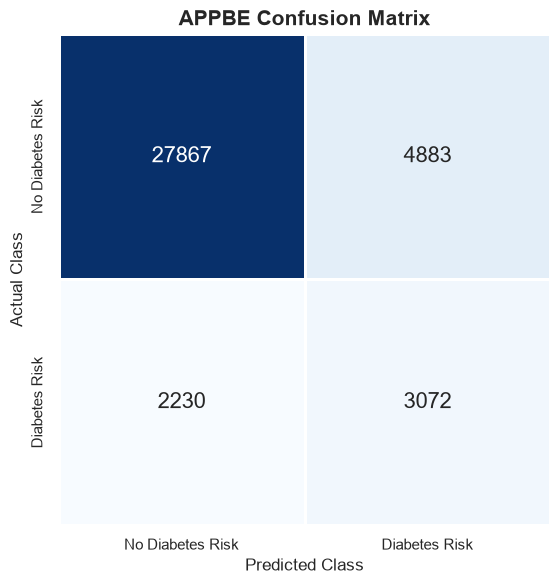

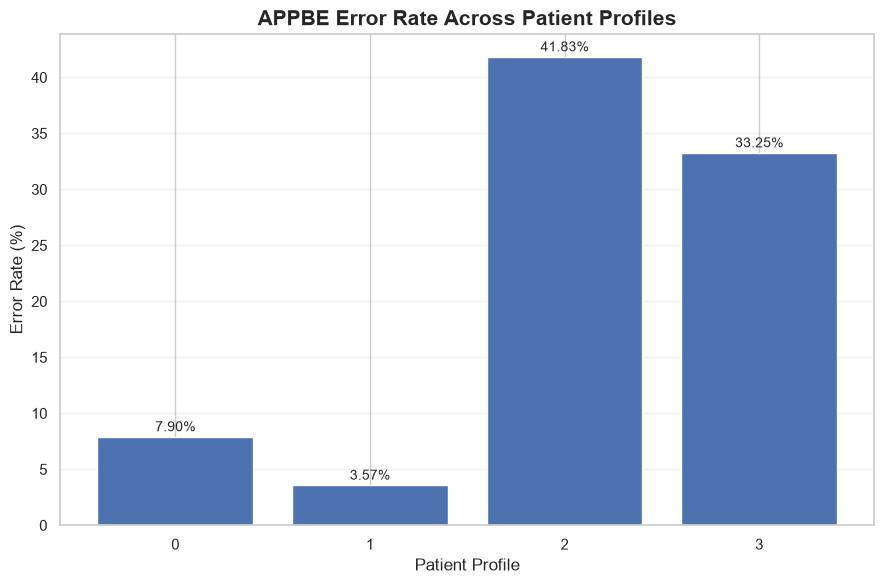

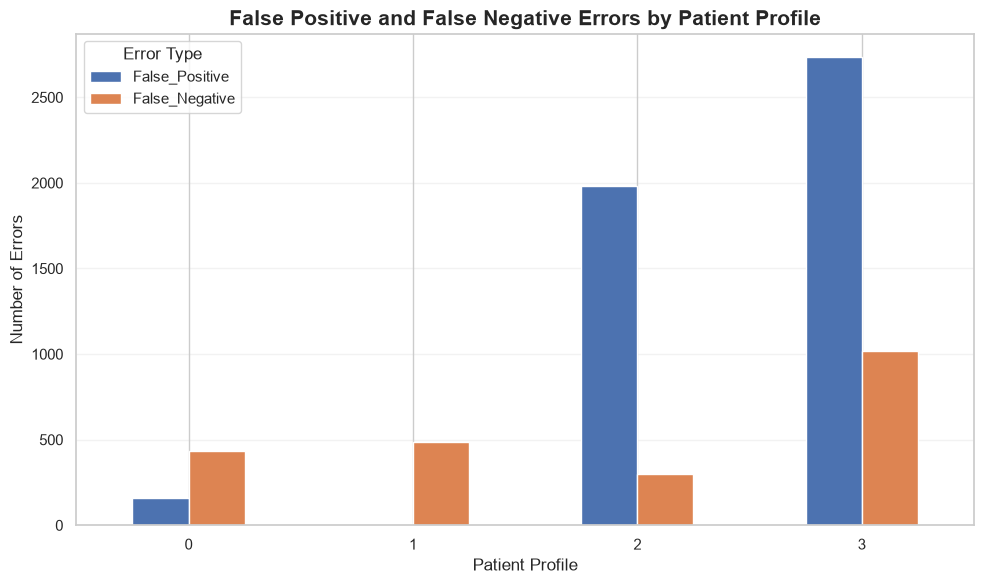

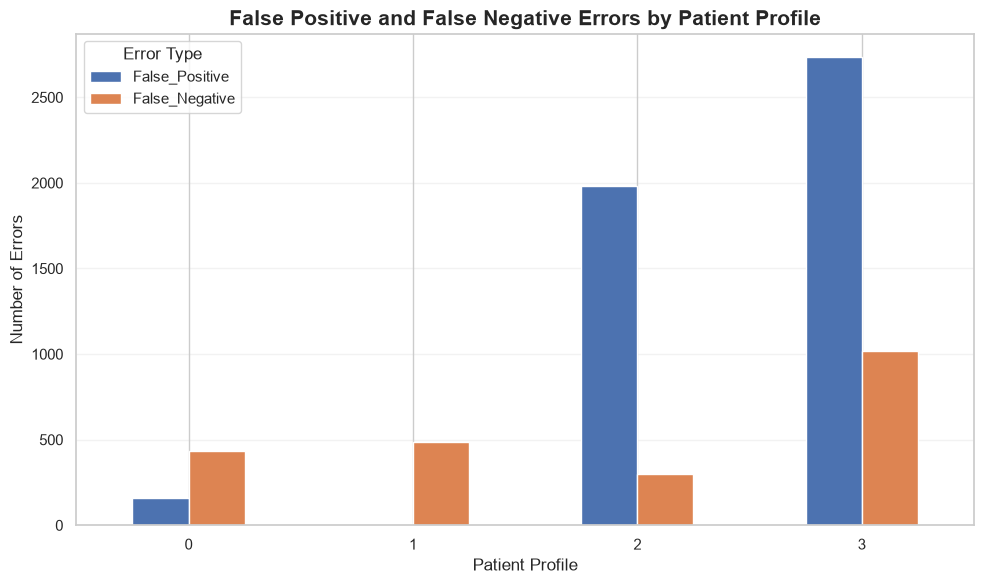

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


error_df = X_test.copy()

error_df["Actual"] = np.asarray(y_test)
error_df["Predicted"] = np.asarray(appbe_prediction)
error_df["Probability"] = np.asarray(appbe_probability)
error_df["Profile"] = np.asarray(test_profiles)


error_df["Correct"] = (
    error_df["Actual"] == error_df["Predicted"]
)


error_df["Prediction_Type"] = np.select(
    [
        (error_df["Actual"] == 0) &
        (error_df["Predicted"] == 0),

        (error_df["Actual"] == 0) &
        (error_df["Predicted"] == 1),

        (error_df["Actual"] == 1) &
        (error_df["Predicted"] == 0),

        (error_df["Actual"] == 1) &
        (error_df["Predicted"] == 1)
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Unknown"
)



cm = confusion_matrix(
    error_df["Actual"],
    error_df["Predicted"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    annot_kws={"size": 16}
)

plt.title(
    "APPBE Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.xticks(
    [0.5, 1.5],
    ["No Diabetes Risk", "Diabetes Risk"]
)

plt.yticks(
    [0.5, 1.5],
    ["No Diabetes Risk", "Diabetes Risk"],
    rotation=90
)

plt.tight_layout()
plt.show()



profile_error = (
    error_df
    .groupby("Profile")
    .agg(
        Patients=("Actual", "count"),
        Errors=("Correct", lambda x: (~x).sum())
    )
)

profile_error["Error_Rate"] = (
    profile_error["Errors"] /
    profile_error["Patients"] * 100
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    profile_error.index.astype(str),
    profile_error["Error_Rate"]
)

plt.title(
    "APPBE Error Rate Across Patient Profiles",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Patient Profile",
    fontsize=12
)

plt.ylabel(
    "Error Rate (%)",
    fontsize=12
)

plt.grid(
    axis="y",
    alpha=0.25
)


for bar, value in zip(
    bars,
    profile_error["Error_Rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()



profile_fp_fn = (
    error_df
    .groupby("Profile")
    .agg(
        False_Positive=(
            "Prediction_Type",
            lambda x:
            (x == "False Positive").sum()
        ),

        False_Negative=(
            "Prediction_Type",
            lambda x:
            (x == "False Negative").sum()
        )
    )
)

profile_fp_fn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "False Positive and False Negative Errors by Patient Profile",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Patient Profile",
    fontsize=12
)

plt.ylabel(
    "Number of Errors",
    fontsize=12
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Error Type"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

profile_fp_fn = (
    error_df
    .groupby("Profile")
    .agg(
        False_Positive=(
            "Prediction_Type",
            lambda x:
            (x == "False Positive").sum()
        ),

        False_Negative=(
            "Prediction_Type",
            lambda x:
            (x == "False Negative").sum()
        )
    )
)

profile_fp_fn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "False Positive and False Negative Errors by Patient Profile",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Patient Profile",
    fontsize=12
)

plt.ylabel(
    "Number of Errors",
    fontsize=12
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Error Type"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.savefig("Profile-wise Error analyis; c.png", dpi=600, bbox_inches="tight")

plt.show()

In [73]:
X_all_scaled = scaler.transform(X)


cluster_labels = kmeans.predict(X_all_scaled)

print("Complete dataset profile assignment completed.")
print("Number of patients:", len(cluster_labels))
print("Number of profiles:", len(np.unique(cluster_labels)))


profile_counts = pd.Series(cluster_labels).value_counts().sort_index()

display(profile_counts)

Complete dataset profile assignment completed.
Number of patients: 253680
Number of profiles: 4


0    49271
1    92691
2    36489
3    75229
Name: count, dtype: int64

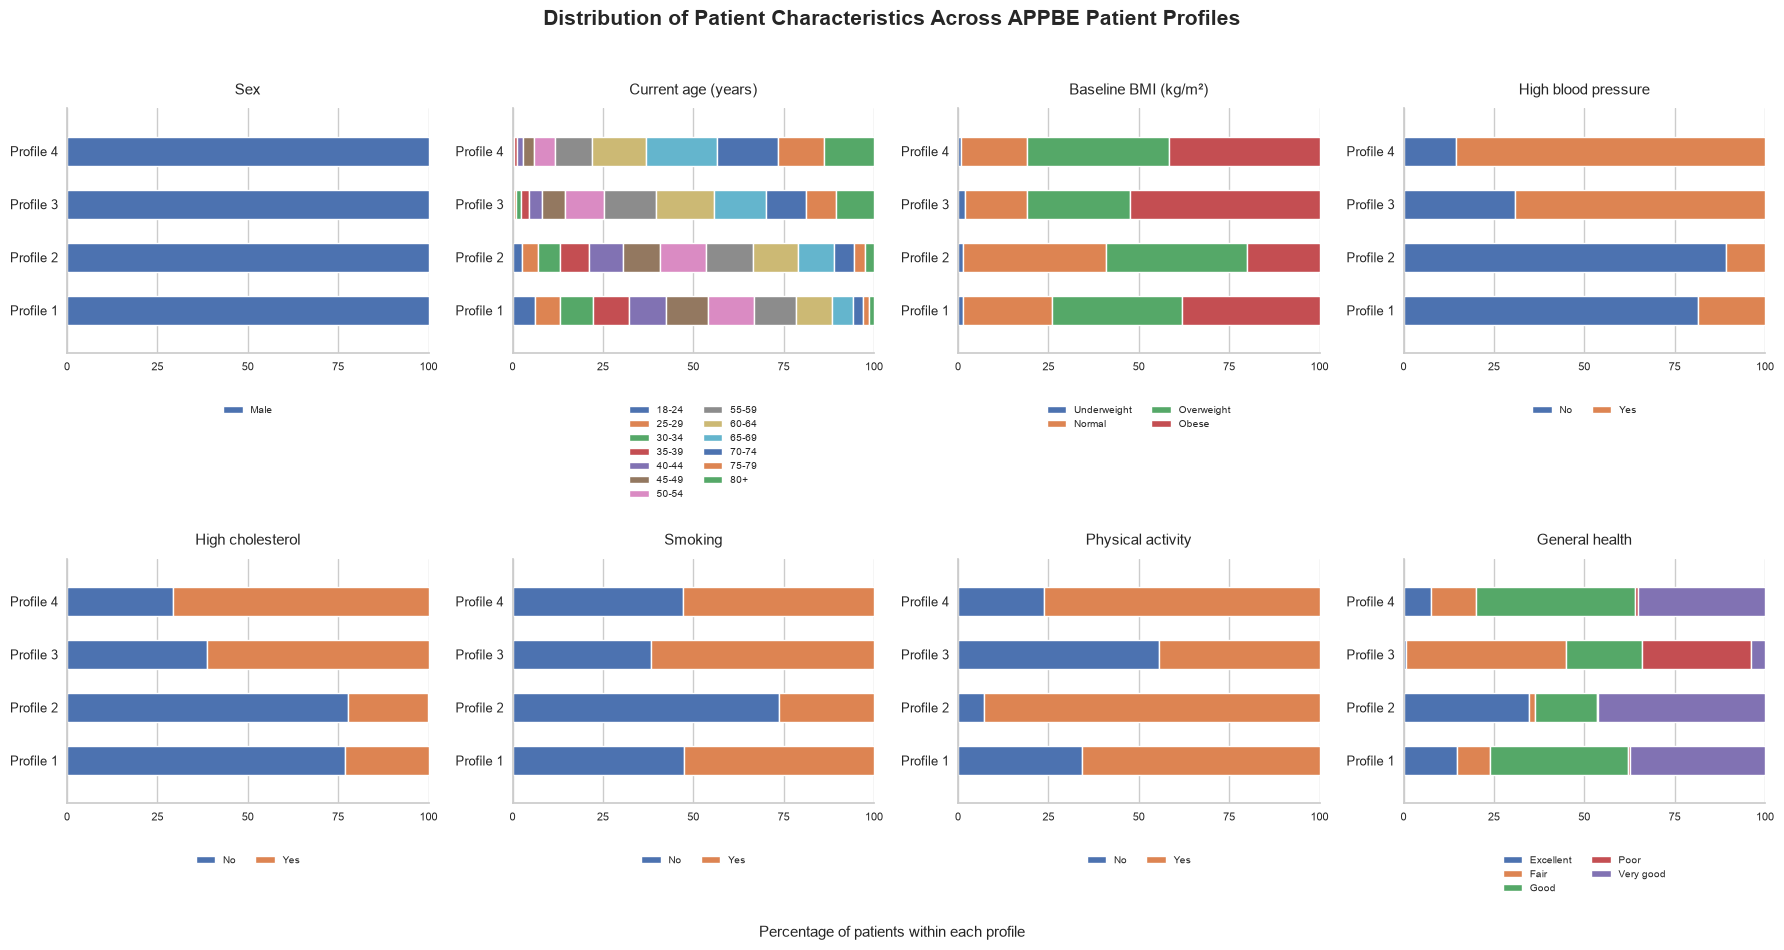

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



plot_df = df.copy()


plot_df["Patient_Profile"] = cluster_labels



age_mapping = {
    1: "18-24",
    2: "25-29",
    3: "30-34",
    4: "35-39",
    5: "40-44",
    6: "45-49",
    7: "50-54",
    8: "55-59",
    9: "60-64",
    10: "65-69",
    11: "70-74",
    12: "75-79",
    13: "80+"
}

plot_df["Age_Group"] = plot_df["Age"].map(age_mapping)


plot_df["BMI_Group"] = pd.cut(
    plot_df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obese"
    ],
    right=False
)



plot_df["Sex_Group"] = plot_df["Sex"].map({
    1: "Male",
    2: "Female"
})



plot_df["Blood_Pressure"] = plot_df["HighBP"].map({
    0: "No",
    1: "Yes"
})



plot_df["Cholesterol"] = plot_df["HighChol"].map({
    0: "No",
    1: "Yes"
})



plot_df["Smoking"] = plot_df["Smoker"].map({
    0: "No",
    1: "Yes"
})



plot_df["Physical_Activity"] = plot_df["PhysActivity"].map({
    0: "No",
    1: "Yes"
})


gen_health_mapping = {
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
}

plot_df["General_Health"] = plot_df["GenHlth"].map(gen_health_mapping)



plot_df["Heart_Disease"] = plot_df["HeartDiseaseorAttack"].map({
    0: "No",
    1: "Yes"
})



characteristics = {
    "Sex": "Sex_Group",
    "Current age (years)": "Age_Group",
    "Baseline BMI (kg/m²)": "BMI_Group",
    "High blood pressure": "Blood_Pressure",
    "High cholesterol": "Cholesterol",
    "Smoking": "Smoking",
    "Physical activity": "Physical_Activity",
    "General health": "General_Health"
}



fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9)
)

axes = axes.flatten()

profiles = sorted(plot_df["Patient_Profile"].dropna().unique())


for ax, (title, column) in zip(axes, characteristics.items()):

    
    table = pd.crosstab(
        plot_df["Patient_Profile"],
        plot_df[column],
        normalize="index"
    ) * 100

    
    table = table.reindex(profiles)

    
    table = table.dropna(axis=1, how="all")

    
    left = np.zeros(len(table))

    for category in table.columns:

        values = table[category].fillna(0).values

        ax.barh(
            np.arange(len(table)),
            values,
            left=left,
            height=0.55,
            label=str(category)
        )

        left += values

    

    ax.set_title(
        title,
        fontsize=11,
        pad=10
    )

    ax.set_xlim(0, 100)

    ax.set_yticks(np.arange(len(table)))

    ax.set_yticklabels(
        [f"Profile {int(x)+1}" for x in table.index],
        fontsize=9
    )

    
    ax.set_xticks([0, 25, 50, 75, 100])

    ax.set_xticklabels(
        ["0", "25", "50", "75", "100"],
        fontsize=8
    )

    ax.tick_params(
        axis="both",
        length=3
    )

    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

   
    ax.margins(y=0.15)

    
    ax.legend(
        fontsize=7,
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2
    )




fig.suptitle(
    "Distribution of Patient Characteristics Across APPBE Patient Profiles",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Percentage of patients within each profile",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.savefig("madam chart; c.png", dpi=600, bbox_inches="tight")


plt.show()